# Activity 8: Numerical Integration

### Trapezoidal vs Simpson Rules of Integration

Like in the differentiation activity we will experimentally measure convergence rates of our algorithms.

Given $n$ divisions, thus $n+1$ points to compute our integral over, our two methods are:

**Composite Trapezoidal Rule**
$$\int_a^b f(x)\,dx \approx \frac{h}{2} \left[
f(a) + 2\sum_{i=1}^{n-1} f(x_i) + f(b)
\right]$$

**Composite Simpson's Rule**
$$\int_a^b f(x)\,dx \approx \frac{h}{3} \left[
f(a) + 4\sum_{\substack{i=1 \\ i \text{ odd}}}^{n-1} f(x_i)
+ 2\sum_{\substack{i=2 \\ i \text{ even}}}^{n-2} f(x_i)
+ f(b)
\right]$$

given $h = \frac{b-a}{n}$, $x_i = a+ih$

In [1]:
import numpy as np
import matplotlib.pyplot as plt


**1. Complete the two methods to approximate $\int_a^b f(x) dx$**

In [2]:
def composite_trapezoid(f, a, b, N):
    "return approximate value of integral""

    #complete me
    return

def composite_simpson(f, a, b, N):
    "return approximate value of integral""
    "*note that this method fails for odd N of divisions*"
    #complete me
    return


Let's approximate $\int_0^\pi\sin(x) dx$ using both methods.

Compute the relative and absolute errors since we know the ground truth solution for this function. 

**1. For n = 2** Print the ground truth solution, trapezoidal method solution, Simpson's method solution, and absolute error for each method.

In [4]:
f = np.sin
a, b = 0, np.pi
exact = 2.0

Ns = [2]

trap_err = []
simp_err = []

for N in Ns:
    trap = composite_trapezoid(f, a, b, N)
    trap_err = abs(trap - exact)
    print(trap, trap_err)
    
    if N % 2 == 0:
        simp = composite_simpson(f, a, b, N)
        simp_err = abs(simp - exact)
        print(simp, simp_err)



1.5707963267948966 0.42920367320510344
2.0943951023931953 0.09439510239319526


**2. Now, plot absolute error vs $h$ for $N = 2^{1,2,3,4,5,6,7}$** (to ensure all n are even)

I found that plotting on a log-log plot helped me compare the methods best, and you will need a log-log plot for the next part.

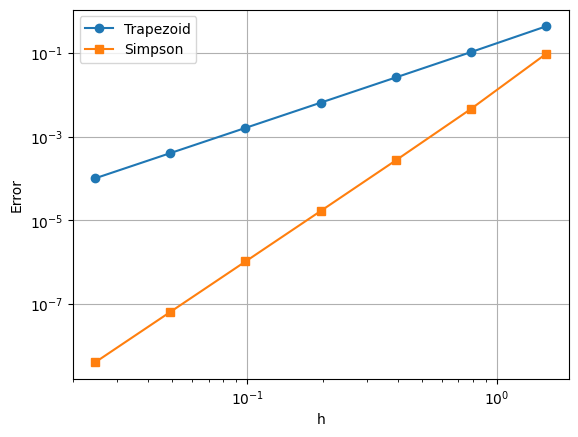

In [11]:
hs = (b-a)/Ns
plt.figure()
plt.loglog(hs, trap_err, 'o-', label="Trapezoid")
plt.loglog(hs, simp_err, 's-', label="Simpson")
plt.xlabel("h")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.show()

In [5]:

Ns = 2**np.arange(1,8)

trap_err = []
simp_err = []

for N in Ns:
    trap = composite_trapezoid(f, a, b, N)
    trap_err.append(abs(trap - exact))
    
    if N % 2 == 0:
        simp = composite_simpson(f, a, b, N)
        simp_err.append(abs(simp - exact))

**3.** Our error terms are of the form $e = ah^p$ if we $\log$ both sides we should see the linear relation in the log-log plot above. **What does the slope represent in our log-log plot?**

**In the cell below, use $\LaTeX$ to show your work in finding the slope meaning and describe.**

type here!

**4. determine order of the error**

Now, find the slope above. You can do this explicity, or use a fitting function (e.g. `np.polyfit`).

Describe your findings. Do the results agree with analytically derived error calculations?

In [14]:
trap_slope = np.polyfit(np.log(hs), np.log(trap_err), 1)[0]
simp_slope = np.polyfit(np.log(hs), np.log(simp_err), 1)[0]

print("Trapezoid slope ≈", trap_slope)
print("Simpson slope ≈", simp_slope)


Trapezoid slope ≈ 2.007799651289077
Simpson slope ≈ 4.060147639547375


Type here